In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [162]:
df_customer_info=pd.read_csv("olist_customers_dataset.csv")
df_geolocation=pd.read_csv("olist_geolocation_dataset.csv")
df_order_items=pd.read_csv("olist_order_items_dataset.csv")
df_order_payment=pd.read_csv("olist_order_payments_dataset.csv")
df_order_review=pd.read_csv("olist_order_reviews_dataset.csv")
df_orders=pd.read_csv("olist_orders_dataset.csv")
df_products=pd.read_csv("olist_products_dataset.csv")
df_seller_info=pd.read_csv("olist_sellers_dataset.csv")
df_product_cat=pd.read_csv("product_category_name_translation.csv")

In [163]:
files=[df_customer_info,df_geolocation,df_order_items,df_order_payment,df_order_review,df_orders,df_products,df_product_cat,df_seller_info]

In [164]:
for file in files:
    print(file.columns)

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Index(['product_id', 'prod

In [165]:
for file in files:
    print('Shape :',file.shape)
    print(file.info())
    print('Duplicate Values: ',file.duplicated().sum())
    print('Null counts :\n',file.isnull().sum())
    print(f'{'*'*50} \n')

Shape : (99441, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None
Duplicate Values:  0
Null counts :
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
************************************************** 

Shape : (1000163, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dty

In [166]:
for file in files:
    file.drop_duplicates(inplace=True)

In [167]:
col=  ['order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date']
for i in col:
    df_orders[i]=pd.to_datetime(df_orders[i])

# EDA

# Customer Behavior Analysis

In [168]:
cust_analysis=df_customer_info.merge(df_orders,on="customer_id",how='inner')

In [169]:
cust_analysis.rename(columns={'customer_state_y':'customer_state'},inplace=True)
cust_analysis.rename(columns={'customer_city_y':'customer_city'},inplace=True)

In [170]:
state_wise_orders=cust_analysis.groupby("customer_state")['order_id'].count().sort_values(ascending=False).reset_index(name='order_count')

In [171]:
state_wise_orders['order_%']=state_wise_orders['order_count']*100/state_wise_orders['order_count'].sum()

In [172]:
state_wise_orders.head()

,customer_state,order_count,order_%
0,SP,41746,41.980672
1,RJ,12852,12.924247
2,MG,11635,11.700405
3,RS,5466,5.496727
4,PR,5045,5.073360


**SP state consist of nearly 42% of total orders whereas there are 16 state where order_percentage is less than 1%
Thats means this ecommerce platform heavely depends on order from SP state.**

In [173]:
city_wise_orders=cust_analysis.groupby("customer_city")['order_id'].count().sort_values(ascending=False).reset_index(name='order_count')

In [174]:
city_wise_orders['order_%']=city_wise_orders['order_count']*100/city_wise_orders['order_count'].sum()

In [175]:
city_wise_orders

,customer_city,order_count,order_%
0,sao paulo,15540,15.627357
1,rio de janeiro,6882,6.920687
2,belo horizonte,2773,2.788588
3,brasilia,2131,2.142979
4,curitiba,1521,1.529550
...,...,...,...
4114,agisse,1,0.001006
4115,vieiras,1,0.001006
4116,bertopolis,1,0.001006
4117,abadiania,1,0.001006


In [176]:
for i  in cust_analysis.columns:
    print(i,':', cust_analysis[i].duplicated().sum())

customer_id : 0
customer_unique_id : 3345
customer_zip_code_prefix : 84447
customer_city : 95322
customer_state : 99414
order_id : 0
order_status : 99433
order_purchase_timestamp : 566
order_approved_at : 8707
order_delivered_carrier_date : 18422
order_delivered_customer_date : 3776
order_estimated_delivery_date : 98982


In [177]:
repeated_cust=cust_analysis.groupby('customer_unique_id')['order_id'].count().sort_values(ascending=False).reset_index(name='order_count')
repeated_cust

,customer_unique_id,order_count
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,1b6c7548a2a1f9037c1fd3ddfed95f33,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,ca77025e7201e3b30c44b472ff346268,7
...,...,...
96091,ffeefd086fc667aaf6595c8fe3d22d54,1
96092,ffef0ffa736c7b3d9af741611089729b,1
96093,fff1afc79f6b5db1e235a4a6c30ceda7,1
96094,fff1bdd5c5e37ca79dd74deeb91aa5b6,1


In [178]:
print('''Loyal Customer list''')
repeated_cust[repeated_cust['order_count']>6]

Loyal Customer list


,customer_unique_id,order_count
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,1b6c7548a2a1f9037c1fd3ddfed95f33,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,ca77025e7201e3b30c44b472ff346268,7


In [179]:
repeated_cust[repeated_cust['order_count']>1].count()

customer_unique_id    2997
order_count           2997
dtype: int64

In [180]:
cancelled=cust_analysis[cust_analysis['order_status']=='canceled'].groupby('customer_state')['order_id'].count().sort_values(ascending=False).reset_index(name='order_cancel_num')
cancelled

,customer_state,order_cancel_num
0,SP,327
1,RJ,86
2,MG,64
3,RS,25
4,PR,22
5,SC,19
6,BA,16
7,GO,13
8,ES,9
9,CE,7


In [181]:
cancelled=state_wise_orders.merge(cancelled,on='customer_state',how='inner')

In [182]:
cancelled

,customer_state,order_count,order_%,order_cancel_num
0,SP,41746,41.980672,327
1,RJ,12852,12.924247,86
2,MG,11635,11.700405,64
3,RS,5466,5.496727,25
4,PR,5045,5.073360,22
5,SC,3637,3.657445,19
6,BA,3380,3.399000,16
7,DF,2140,2.152030,7
8,ES,2033,2.044428,9
9,GO,2020,2.031355,13


In [183]:
# cancelled.rename(columns={'order_id':'cancelled_order'},inplace=True)
cancelled

,customer_state,order_count,order_%,order_cancel_num
0,SP,41746,41.980672,327
1,RJ,12852,12.924247,86
2,MG,11635,11.700405,64
3,RS,5466,5.496727,25
4,PR,5045,5.073360,22
5,SC,3637,3.657445,19
6,BA,3380,3.399000,16
7,DF,2140,2.152030,7
8,ES,2033,2.044428,9
9,GO,2020,2.031355,13


In [184]:
cancelled['cancel_order_rate']=cancelled['order_cancel_num']*100/cancelled['order_count']

In [185]:
cancelled.sort_values(by='cancel_order_rate',ascending=False).head(10)

,customer_state,order_count,order_%,order_cancel_num,cancel_order_rate
22,RR,46,0.046259,1,2.173913
21,RO,253,0.254422,3,1.185771
17,PI,495,0.497783,4,0.808081
0,SP,41746,41.980672,327,0.783309
1,RJ,12852,12.924247,86,0.669157
9,GO,2020,2.031355,13,0.643564
2,MG,11635,11.700405,64,0.550064
14,MA,747,0.751199,4,0.535475
11,CE,1336,1.343510,7,0.523952
5,SC,3637,3.657445,19,0.522409


In [186]:
cust_analysis.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date'],
      dtype='object')

In [187]:
cancelled.head(4)

,customer_state,order_count,order_%,order_cancel_num,cancel_order_rate
0,SP,41746,41.980672,327,0.783309
1,RJ,12852,12.924247,86,0.669157
2,MG,11635,11.700405,64,0.550064
3,RS,5466,5.496727,25,0.457373


In [188]:
cust_analysis['order_purchase_timestamp'].isnull().sum()

np.int64(0)

In [189]:
cust_analysis['month_year']=cust_analysis['order_purchase_timestamp'].dt.to_period("M")

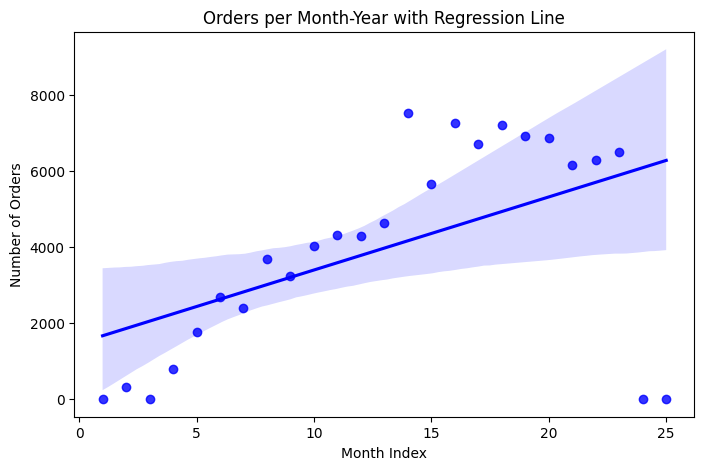

In [190]:
grouped = cust_analysis.groupby("month_year")["order_id"].count().reset_index()

# Convert Period to integer index
grouped["month_index"] = grouped["month_year"].apply(lambda x: x.to_timestamp()).rank().astype(int)

plt.figure(figsize=(8,5))
sns.regplot(
    data=grouped,
    x="month_index", 
    y="order_id", 
    scatter=True, 
    marker="o", 
    color="blue", 
    order=1
)

plt.title("Orders per Month-Year with Regression Line")
plt.xlabel("Month Index")
plt.ylabel("Number of Orders")
plt.xticks(None)
plt.show()



# REVENUE ANALYSIS

In [191]:
revenue_analysis=df_orders.merge(df_order_items,on='order_id',how='inner')
revenue_analysis=revenue_analysis.merge(df_order_payment,on='order_id',how='inner')

In [192]:
revenue_analysis

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1,credit_card,3,179.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117596,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,1,credit_card,3,195.00
117597,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,1,credit_card,5,271.01
117598,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,1,credit_card,4,441.16
117599,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,1,credit_card,4,441.16


In [193]:
revenue_analysis.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [194]:
revenue_analysis=revenue_analysis.sort_values(by=['order_id','payment_installments'],ascending=[True,False])
revenue_analysis.drop_duplicates(subset='order_id',inplace=True)

In [195]:
revenue_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98665 entries, 100690 to 70526
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       98665 non-null  object        
 1   customer_id                    98665 non-null  object        
 2   order_status                   98665 non-null  object        
 3   order_purchase_timestamp       98665 non-null  datetime64[ns]
 4   order_approved_at              98651 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97656 non-null  datetime64[ns]
 6   order_delivered_customer_date  96475 non-null  datetime64[ns]
 7   order_estimated_delivery_date  98665 non-null  datetime64[ns]
 8   order_item_id                  98665 non-null  int64         
 9   product_id                     98665 non-null  object        
 10  seller_id                      98665 non-null  object        
 11  shipping_limit_

In [196]:
revenue_analysis[revenue_analysis['payment_value'] != revenue_analysis['price']+revenue_analysis['freight_value']]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
6126,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,1,credit_card,3,218.04
81956,00048cc3ae777c65dbb7d2a0634bc1ea,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15 21:42:34,2017-05-17 03:55:27,2017-05-17 11:05:55,2017-05-22 13:44:35,2017-06-06,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69,1,boleto,1,34.59
32463,00063b381e2406b52ad429470734ebd5,6a899e55865de6549a58d2c6845e5604,delivered,2018-07-27 17:21:27,2018-07-27 18:00:06,2018-07-30 14:52:00,2018-08-07 13:56:52,2018-08-07,1,f177554ea93259a5b282f24e33f65ab6,8602a61d680a10a82cceeeda0d99ea3d,2018-07-31 17:30:39,45.00,12.98,1,credit_card,5,57.98
63762,0008288aa423d2a3f00fcb17cd7d8719,2355af7c75e7c98b43a87b2a7f210dc5,delivered,2018-02-13 22:10:21,2018-02-15 03:55:52,2018-02-20 18:23:28,2018-02-26 13:55:22,2018-03-06,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37,1,boleto,1,126.54
54583,0009792311464db532ff765bf7b182ae,2a30c97668e81df7c17a8b14447aeeba,delivered,2018-08-14 20:43:09,2018-08-15 12:15:10,2018-08-15 15:28:00,2018-08-22 12:02:27,2018-08-28,1,8cab8abac59158715e0d70a36c807415,530ec6109d11eaaf87999465c6afee01,2018-08-17 12:15:10,99.90,27.65,1,boleto,1,127.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89552,fffb0b1a50e65c449020434fa835e078,46b385c6d972b73cbcf797a8b16c072d,delivered,2017-04-12 16:35:43,2017-04-12 16:45:12,2017-04-27 09:26:54,2017-05-17 11:38:22,2017-05-15,1,e7be84ea9462aac5e2b0b08eb35ba7f1,36a968b544695394e4e9d7572688598f,2017-04-28 16:45:12,4.90,10.96,1,credit_card,1,15.86
62398,fffb2ef8874127f75b52b643880fd7e0,ca8374c00203cec663bc1eabf0aaede4,delivered,2018-03-30 15:36:49,2018-04-03 05:08:33,2018-04-03 15:12:19,2018-04-16 16:56:38,2018-04-27,1,ebceb9726cf5c6187b48e17fe58747b0,609e1a9a6c2539919b8205cf7c4e6ff0,2018-04-09 05:08:33,17.90,22.06,1,boleto,1,39.96
73131,fffb9224b6fc7c43ebb0904318b10b5f,4d3abb73ceb86353aeadbe698aa9d5cb,delivered,2017-10-27 16:51:00,2017-10-28 02:55:58,2017-11-10 19:31:52,2017-11-17 19:41:42,2017-11-27,1,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19,1,boleto,1,356.76
62271,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,1,credit_card,3,116.85


In [197]:

revenue_analysis['payment_value'] = revenue_analysis['payment_value'].round(2)
revenue_analysis['price'] = revenue_analysis['price'].round(2)
revenue_analysis['freight_value'] = revenue_analysis['freight_value'].round(2)

mismatches = revenue_analysis[
    revenue_analysis['payment_value'] != revenue_analysis['price'] + revenue_analysis['freight_value']
]


In [198]:
revenue_analysis[revenue_analysis['order_status'] != 'canceled']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
100690,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,1,credit_card,2,72.19
84871,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,1,credit_card,3,259.83
7361,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,1,credit_card,5,216.87
26602,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,1,credit_card,2,25.78
6126,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,1,credit_card,3,218.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93898,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,1,boleto,1,343.40
82797,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,1,boleto,1,386.53
62271,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,1,credit_card,3,116.85
70680,fffe18544ffabc95dfada21779c9644f,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,1,credit_card,3,64.71


In [199]:
payment=revenue_analysis.groupby("payment_type")['payment_value'].sum().reset_index()
payment['payment %']=round(payment['payment_value']*100/payment['payment_value'].sum(),2)
payment

,payment_type,payment_value,payment %
0,boleto,2842240.16,18.20
1,credit_card,12375277.85,79.24
2,debit_card,215035.73,1.38
3,voucher,184928.11,1.18


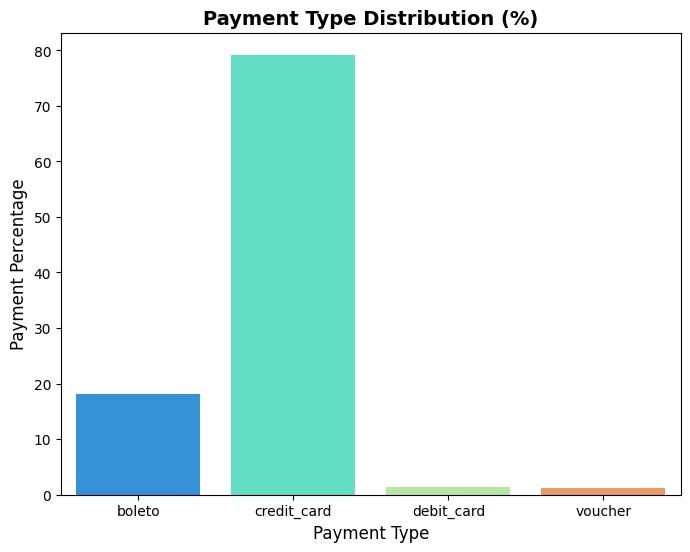

In [200]:
plt.figure(figsize=(8,6))  # set figure size

sns.barplot(
    data=payment,
    x='payment_type',
    y='payment %',
    palette='rainbow'
)

plt.title('Payment Type Distribution (%)', fontsize=14, fontweight='bold')
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Payment Percentage', fontsize=12)

plt.show()

In [201]:
payment_meth=revenue_analysis.groupby(["payment_type"])['payment_type'].count()

In [202]:
payment_meth=payment_meth.reset_index(name='payment_count')

In [203]:
payment=payment_meth.merge(payment,on='payment_type')
payment['payment_value/count']=payment['payment_value']/payment['payment_count']
payment

,payment_type,payment_count,payment_value,payment %,payment_value/count
0,boleto,19614,2842240.16,18.20,144.908747
1,credit_card,75240,12375277.85,79.24,164.477377
2,debit_card,1520,215035.73,1.38,141.470875
3,voucher,2291,184928.11,1.18,80.719385


<Axes: xlabel='payment_value', ylabel='Count'>

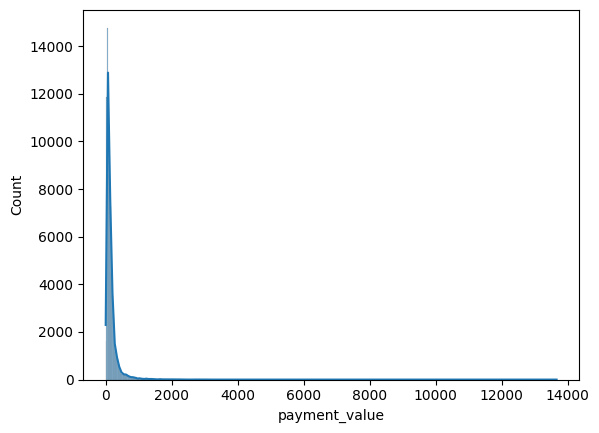

In [204]:
sns.histplot(revenue_analysis['payment_value'],kde=True)

# PRODUCT PERFORMANCE 

In [205]:
product_analysis=df_products.merge(df_order_items,on='product_id',how='inner')
product_analysis=product_analysis.merge(df_product_cat,on='product_category_name',how='outer')

In [206]:
product_analysis

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english
0,07f01b6fcacc1b187a71e5074199db2d,agro_industria_e_comercio,39.0,430.0,1.0,16400.0,63.0,66.0,56.0,21577126c19bf11a0b91592e5844ba78,1,6481e96574816ead57975da2c0f6d80d,2018-03-22 17:28:45,57.0,29.99,agro_industry_and_commerce
1,613d093272cb8f74f25a01e430155a6a,agro_industria_e_comercio,39.0,326.0,1.0,1050.0,38.0,41.0,39.0,8c49b48367363f2894bccea3248be15d,1,6481e96574816ead57975da2c0f6d80d,2018-01-18 13:48:55,29.5,9.94,agro_industry_and_commerce
2,980ecbcc15fe174ec1e5757c4d75b1bf,agro_industria_e_comercio,48.0,157.0,1.0,250.0,17.0,3.0,10.0,a3a09d0a201027720550355df943b598,1,e59aa562b9f8076dd550fcddf0e73491,2018-01-24 20:14:08,23.0,15.79,agro_industry_and_commerce
3,980ecbcc15fe174ec1e5757c4d75b1bf,agro_industria_e_comercio,48.0,157.0,1.0,250.0,17.0,3.0,10.0,a3a09d0a201027720550355df943b598,2,e59aa562b9f8076dd550fcddf0e73491,2018-01-24 20:14:08,23.0,15.79,agro_industry_and_commerce
4,980ecbcc15fe174ec1e5757c4d75b1bf,agro_industria_e_comercio,48.0,157.0,1.0,250.0,17.0,3.0,10.0,a3a09d0a201027720550355df943b598,3,e59aa562b9f8076dd550fcddf0e73491,2018-01-24 20:14:08,23.0,15.79,agro_industry_and_commerce
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0,a908872306574c9405b29a838aee5521,2,0c8380b62e38e8a1e6adbeba7eb9688c,2018-07-30 17:15:20,31.9,20.12,NaN
112646,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0,b9138517d788504f3732765e32ffc3d7,1,e5d4b2b0c3bca22085f7a19a28de0c42,2017-11-30 05:39:25,64.9,15.89,NaN
112647,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0,5a06ec99090e75d00d2b33b0efdce2f4,1,1b8b75e227c9a9c100d0c210fb6176ce,2017-02-05 21:33:14,110.0,15.53,NaN
112648,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0,fe51db9ff7a67edc7468c14e0a2e9aa1,1,1b8b75e227c9a9c100d0c210fb6176ce,2017-02-10 17:10:51,110.0,15.98,NaN


In [207]:
prod_cat=product_analysis.groupby(['product_category_name_english'])['price'].sum().sort_values(ascending=False).reset_index()
prod_cat

,product_category_name_english,price
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
...,...,...
66,flowers,1110.04
67,home_comfort_2,760.27
68,cds_dvds_musicals,730.00
69,fashion_childrens_clothes,569.85


In [208]:
prd_cat_analysis=product_analysis.groupby(['product_category_name_english'])['order_id'].count().sort_values(ascending=False).reset_index(name='order_count')

In [209]:
prd_cat_analysis

,product_category_name_english,order_count
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827
...,...,...
66,arts_and_craftmanship,24
67,la_cuisine,14
68,cds_dvds_musicals,14
69,fashion_childrens_clothes,8


In [210]:
# It is clear that most people purchase bed bath table category product but the revenue generation is mostly from health_beauty products.

In [211]:
product_analysis=product_analysis.merge(df_orders,on='order_id',how='outer')
product_analysis=product_analysis.merge(df_customer_info,on='customer_id',how='outer')

In [212]:
product_analysis

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,...,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,64315bd8c0c47303179dd2e25b579d00,brinquedos,55.0,889.0,1.0,4267.0,46.0,39.0,22.0,5f79b5b0931d63f1a42989eb65b9da6e,...,delivered,2017-11-14 16:08:26,2017-11-14 16:35:32,2017-11-17 15:32:08,2017-11-28 15:41:30,2017-12-04,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP
1,84183944dc7cddca87a5d384452c1d3c,beleza_saude,57.0,2563.0,2.0,150.0,16.0,2.0,11.0,a44895d095d7e0702b6a162fa2dbeced,...,delivered,2017-07-16 09:40:32,2017-07-16 09:55:12,2017-07-19 19:09:37,2017-07-25 18:57:33,2017-08-04,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG
2,9df2b21ec85378d71df4404712e17478,bebes,45.0,1042.0,2.0,750.0,21.0,23.0,35.0,316a104623542e4d75189bb372bc5f8d,...,delivered,2017-02-28 11:06:43,2017-02-28 11:15:20,2017-03-01 15:24:20,2017-03-06 08:57:49,2017-03-22,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES
3,af3ec22cce878225aae6d9eb6c7a78eb,cool_stuff,38.0,840.0,1.0,1600.0,40.0,24.0,30.0,5825ce2e88d5346438686b0bba99e5ee,...,delivered,2017-08-16 13:09:20,2017-08-17 03:10:27,2017-08-19 11:34:29,2017-09-13 20:06:02,2017-09-14,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG
4,868b3136c5b206f91b8208fbfdf2cb7c,cama_mesa_banho,57.0,364.0,2.0,800.0,45.0,10.0,34.0,0ab7fb08086d4af9141453c91878ed7a,...,delivered,2018-04-02 13:42:17,2018-04-04 03:10:19,2018-04-04 18:11:09,2018-04-13 20:21:08,2018-04-18,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113420,d5c263f4d651ba657c900ce70a4be7de,telefonia,59.0,458.0,4.0,350.0,20.0,30.0,20.0,8c855550908247a7eff50281b92167a8,...,delivered,2018-05-22 13:36:02,2018-05-22 13:54:37,2018-05-25 13:25:00,2018-06-08 18:03:31,2018-06-29,afbb5a642107cf6bb1ca68e863175f03,22461,rio de janeiro,RJ
113421,e61c78a7343d82c0539d27df0f7dfc31,cama_mesa_banho,60.0,268.0,1.0,2700.0,41.0,8.0,36.0,83b5fc912b2862c5046555ded1483ae9,...,delivered,2018-06-13 16:57:05,2018-06-13 17:20:23,2018-06-15 18:52:00,2018-06-18 18:33:05,2018-06-25,680213db6ebd9e4f24d03280cbe10346,6754,taboao da serra,SP
113422,43ee88561093499d9e571d4db5f20b79,moveis_decoracao,39.0,161.0,3.0,200.0,20.0,20.0,20.0,d0e7be325a1c986babc4e1cdb91edc03,...,delivered,2017-09-02 11:53:32,2017-09-02 12:05:40,2017-09-08 20:04:11,2017-09-14 19:47:40,2017-09-26,48fd7dec70f2b104a1d5e8c5c639102b,37130,alfenas,MG
113423,43ee88561093499d9e571d4db5f20b79,moveis_decoracao,39.0,161.0,3.0,200.0,20.0,20.0,20.0,d0e7be325a1c986babc4e1cdb91edc03,...,delivered,2017-09-02 11:53:32,2017-09-02 12:05:40,2017-09-08 20:04:11,2017-09-14 19:47:40,2017-09-26,48fd7dec70f2b104a1d5e8c5c639102b,37130,alfenas,MG


In [213]:
cust_city_order=product_analysis.groupby(["customer_city","product_category_name_english"])['order_id'].count().reset_index(name='order_count')

In [214]:
city_wise_top_selling_product=cust_city_order.loc[cust_city_order.groupby(['customer_city'])['order_count'].idxmax().reset_index()['order_count'],['customer_city','product_category_name_english','order_count']].sort_values(by='order_count',ascending=False)

In [215]:
city_wise_top_selling_product.reset_index(drop=True)

,customer_city,product_category_name_english,order_count
0,sao paulo,bed_bath_table,1984
1,rio de janeiro,bed_bath_table,854
2,belo horizonte,bed_bath_table,351
3,brasilia,health_beauty,246
4,porto alegre,bed_bath_table,175
...,...,...,...
4090,volta grande,consoles_games,1
4091,viseu,watches_gifts,1
4092,adhemar de barros,auto,1
4093,adrianopolis,fashion_bags_accessories,1


In [216]:
# product_analysis.groupby("product_category_name")['']

In [217]:
product_analysis=product_analysis.merge(df_order_items,on='order_id',how="inner")

In [218]:
prd_cat_price=product_analysis.groupby(['product_category_name_english'])['price_y'].mean().sort_values(ascending=False).reset_index(name='price')
prd_cat_price

,product_category_name_english,price
0,computers,1006.470906
1,small_appliances_home_oven_and_coffee,620.509103
2,home_appliances_2,460.838866
3,fixed_telephony,421.578851
4,agro_industry_and_commerce,346.959277
...,...,...
66,fashio_female_clothing,48.624588
67,food_drink,45.409042
68,flowers,31.935000
69,diapers_and_hygiene,31.651505


In [219]:
prd_cat_price.head(10)

,product_category_name_english,price
0,computers,1006.470906
1,small_appliances_home_oven_and_coffee,620.509103
2,home_appliances_2,460.838866
3,fixed_telephony,421.578851
4,agro_industry_and_commerce,346.959277
5,small_appliances,254.401471
6,musical_instruments,247.059190
7,construction_tools_safety,192.370422
8,air_conditioning,189.074028
9,watches_gifts,182.169665


In [220]:
product_analysis

,product_id_x,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id_y,product_id_y,seller_id_y,shipping_limit_date_y,price_y,freight_value_y
0,64315bd8c0c47303179dd2e25b579d00,brinquedos,55.0,889.0,1.0,4267.0,46.0,39.0,22.0,5f79b5b0931d63f1a42989eb65b9da6e,...,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP,1,64315bd8c0c47303179dd2e25b579d00,7aa4334be125fcdd2ba64b3180029f14,2017-11-21 16:35:32,89.80,24.94
1,84183944dc7cddca87a5d384452c1d3c,beleza_saude,57.0,2563.0,2.0,150.0,16.0,2.0,11.0,a44895d095d7e0702b6a162fa2dbeced,...,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG,1,84183944dc7cddca87a5d384452c1d3c,2a1348e9addc1af5aaa619b1a3679d6b,2017-07-20 09:55:12,54.90,12.51
2,9df2b21ec85378d71df4404712e17478,bebes,45.0,1042.0,2.0,750.0,21.0,23.0,35.0,316a104623542e4d75189bb372bc5f8d,...,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES,1,9df2b21ec85378d71df4404712e17478,46dc3b2cc0980fb8ec44634e21d2718e,2017-03-06 11:15:20,179.99,15.43
3,af3ec22cce878225aae6d9eb6c7a78eb,cool_stuff,38.0,840.0,1.0,1600.0,40.0,24.0,30.0,5825ce2e88d5346438686b0bba99e5ee,...,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG,1,af3ec22cce878225aae6d9eb6c7a78eb,aafe36600ce604f205b86b5084d3d767,2017-08-23 03:10:27,149.90,29.45
4,868b3136c5b206f91b8208fbfdf2cb7c,cama_mesa_banho,57.0,364.0,2.0,800.0,45.0,10.0,34.0,0ab7fb08086d4af9141453c91878ed7a,...,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP,1,868b3136c5b206f91b8208fbfdf2cb7c,4a3ca9315b744ce9f8e9374361493884,2018-04-10 03:10:19,93.00,14.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157217,e61c78a7343d82c0539d27df0f7dfc31,cama_mesa_banho,60.0,268.0,1.0,2700.0,41.0,8.0,36.0,83b5fc912b2862c5046555ded1483ae9,...,680213db6ebd9e4f24d03280cbe10346,6754,taboao da serra,SP,1,e61c78a7343d82c0539d27df0f7dfc31,da8622b14eb17ae2831f4ac5b9dab84a,2018-06-15 17:20:23,199.90,14.23
157218,43ee88561093499d9e571d4db5f20b79,moveis_decoracao,39.0,161.0,3.0,200.0,20.0,20.0,20.0,d0e7be325a1c986babc4e1cdb91edc03,...,48fd7dec70f2b104a1d5e8c5c639102b,37130,alfenas,MG,1,43ee88561093499d9e571d4db5f20b79,23613d49c3ac2bd302259e55c06c050c,2017-09-08 12:05:40,10.90,11.85
157219,43ee88561093499d9e571d4db5f20b79,moveis_decoracao,39.0,161.0,3.0,200.0,20.0,20.0,20.0,d0e7be325a1c986babc4e1cdb91edc03,...,48fd7dec70f2b104a1d5e8c5c639102b,37130,alfenas,MG,2,43ee88561093499d9e571d4db5f20b79,23613d49c3ac2bd302259e55c06c050c,2017-09-08 12:05:40,10.90,11.85
157220,43ee88561093499d9e571d4db5f20b79,moveis_decoracao,39.0,161.0,3.0,200.0,20.0,20.0,20.0,d0e7be325a1c986babc4e1cdb91edc03,...,48fd7dec70f2b104a1d5e8c5c639102b,37130,alfenas,MG,1,43ee88561093499d9e571d4db5f20b79,23613d49c3ac2bd302259e55c06c050c,2017-09-08 12:05:40,10.90,11.85


# SELLER PERFORMANCE

In [221]:
seller_analysis=df_seller_info.merge(df_order_items,on='seller_id',how='outer')
seller_analysis=seller_analysis.merge(df_orders,on='order_id',how='outer')
seller_analysis=seller_analysis.merge(df_order_payment,on='order_id',how='outer')
seller_analysis=seller_analysis.merge(df_order_review,on='order_id',how='outer')

In [222]:
seller_analysis

,seller_id,seller_zip_code_prefix,seller_city,seller_state,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,48436dade18ac8b2bce089ec2a041202,27277.0,volta redonda,SP,00010242fe8c5a6d1ba2dd792cb16214,1.0,4244733e06e7ecb4970a6e2683c13e61,2017-09-19 09:45:35,58.90,13.29,...,1.0,credit_card,2.0,72.19,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,dd7ddc04e1b6c2c614352b383efe2d36,3471.0,sao paulo,SP,00018f77f2f0320c557190d7a144bdd3,1.0,e5f2d52b802189ee658865ca93d83a8f,2017-05-03 11:05:13,239.90,19.93,...,1.0,credit_card,3.0,259.83,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,5b51032eddd242adc84c38acab88f23d,37564.0,borda da mata,MG,000229ec398224ef6ca0657da4fc703e,1.0,c777355d18b72b67abbeef9df44fd0fd,2018-01-18 14:48:30,199.00,17.87,...,1.0,credit_card,5.0,216.87,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31
3,9d7a1d34a5052409006425275ba1c2b4,14403.0,franca,SP,00024acbcdf0a6daa1e931b038114c75,1.0,7634da152a4610f1595efa32f14722fc,2018-08-15 10:10:18,12.99,12.79,...,1.0,credit_card,2.0,25.78,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01
4,df560393f3a51e74553ab94004ba5c87,87900.0,loanda,PR,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,ac6c3623068f30de03045865e4e10089,2017-02-13 13:57:51,199.90,18.14,...,1.0,credit_card,3.0,218.04,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,b8bc237ba3788b23da09c0f1f3a3288c,88303.0,itajai,SC,fffc94f6ce00a00581880bf54a75a037,1.0,4aa6014eceb682077f9dc4bffebc05b0,2018-05-02 04:11:01,299.99,43.41,...,1.0,boleto,1.0,343.40,9185f849f32d82e216a4e025e0c50f5c,5.0,NaN,NaN,2018-05-11 00:00:00,2018-05-14 12:53:47
119139,f3c38ab652836d21de61fb8314b69182,1206.0,sao paulo,SP,fffcd46ef2263f404302a634eb57f7eb,1.0,32e07fd915822b0765e448c4dd74c828,2018-07-20 04:31:48,350.00,36.53,...,1.0,boleto,1.0,386.53,be803f6a93d64719fd685c1cc610918a,5.0,NaN,NaN,2018-07-24 00:00:00,2018-07-25 09:25:29
119140,c3cfdc648177fdbbbb35635a37472c53,80610.0,curitiba,PR,fffce4705a9662cd70adb13d4a31832d,1.0,72a30483855e2eafc67aee5dc2560482,2017-10-30 17:14:25,99.90,16.95,...,1.0,credit_card,3.0,116.85,dbdd81cd59a1a9f94a10a990b4d48dce,5.0,NaN,NaN,2017-10-29 00:00:00,2017-10-29 21:33:52
119141,2b3e4a2a3ea8e01938cabda2a3e5cc79,4733.0,sao paulo,SP,fffe18544ffabc95dfada21779c9644f,1.0,9c422a519119dcad7575db5af1ba540e,2017-08-21 00:04:32,55.99,8.72,...,1.0,credit_card,3.0,64.71,fba117c9ac40d41ca7be54741f471303,5.0,NaN,Recebi o produto antes do prazo e corretamente.,2017-08-17 00:00:00,2017-08-18 12:24:05


In [223]:
seller_info=seller_analysis.groupby(['seller_id','seller_city']).agg(
        total_payment=('payment_value','sum'),
        avg_rating=('review_score','mean')  
    ).sort_values(by='total_payment', ascending=False).reset_index()

In [224]:
seller_info

,seller_id,seller_city,total_payment,avg_rating
0,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,512645.19,3.394773
1,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,312456.49,3.862116
2,4a3ca9315b744ce9f8e9374361493884,ibitinga,306138.80,3.801692
3,1f50f920176fa81dab994f9023523100,sao jose do rio preto,291918.98,3.981583
4,53243585a1d6dc2643021fd1853d8905,lauro de freitas,284903.08,4.071264
...,...,...,...,...
3090,ad14615bdd492b01b0d97922e87cb87f,tubarao,19.21,5.000000
3091,702835e4b785b67a084280efca355756,juiz de fora,18.56,5.000000
3092,4965a7002cca77301c82d3f91b82e1a9,sorocaba,16.36,5.000000
3093,77128dec4bec4878c37ab7d6169d6f26,sao paulo,15.22,5.000000


<Axes: xlabel='avg_rating', ylabel='Count'>

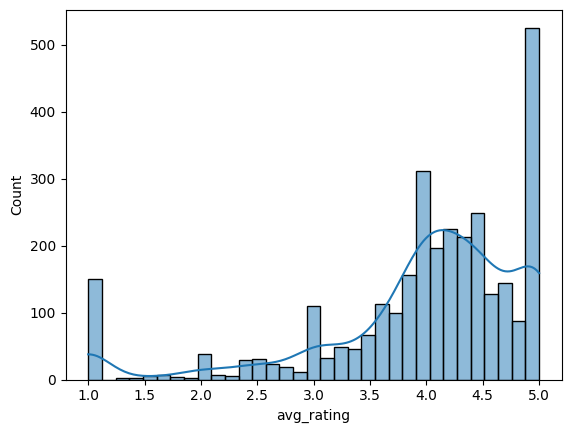

In [225]:
sns.histplot(x=seller_info['avg_rating'],kde=True)

In [226]:
seller_analysis[seller_analysis['review_score']<3]['seller_id'].nunique()

1911

In [227]:
seller_analysis 

,seller_id,seller_zip_code_prefix,seller_city,seller_state,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,48436dade18ac8b2bce089ec2a041202,27277.0,volta redonda,SP,00010242fe8c5a6d1ba2dd792cb16214,1.0,4244733e06e7ecb4970a6e2683c13e61,2017-09-19 09:45:35,58.90,13.29,...,1.0,credit_card,2.0,72.19,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,dd7ddc04e1b6c2c614352b383efe2d36,3471.0,sao paulo,SP,00018f77f2f0320c557190d7a144bdd3,1.0,e5f2d52b802189ee658865ca93d83a8f,2017-05-03 11:05:13,239.90,19.93,...,1.0,credit_card,3.0,259.83,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,5b51032eddd242adc84c38acab88f23d,37564.0,borda da mata,MG,000229ec398224ef6ca0657da4fc703e,1.0,c777355d18b72b67abbeef9df44fd0fd,2018-01-18 14:48:30,199.00,17.87,...,1.0,credit_card,5.0,216.87,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31
3,9d7a1d34a5052409006425275ba1c2b4,14403.0,franca,SP,00024acbcdf0a6daa1e931b038114c75,1.0,7634da152a4610f1595efa32f14722fc,2018-08-15 10:10:18,12.99,12.79,...,1.0,credit_card,2.0,25.78,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01
4,df560393f3a51e74553ab94004ba5c87,87900.0,loanda,PR,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,ac6c3623068f30de03045865e4e10089,2017-02-13 13:57:51,199.90,18.14,...,1.0,credit_card,3.0,218.04,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,b8bc237ba3788b23da09c0f1f3a3288c,88303.0,itajai,SC,fffc94f6ce00a00581880bf54a75a037,1.0,4aa6014eceb682077f9dc4bffebc05b0,2018-05-02 04:11:01,299.99,43.41,...,1.0,boleto,1.0,343.40,9185f849f32d82e216a4e025e0c50f5c,5.0,NaN,NaN,2018-05-11 00:00:00,2018-05-14 12:53:47
119139,f3c38ab652836d21de61fb8314b69182,1206.0,sao paulo,SP,fffcd46ef2263f404302a634eb57f7eb,1.0,32e07fd915822b0765e448c4dd74c828,2018-07-20 04:31:48,350.00,36.53,...,1.0,boleto,1.0,386.53,be803f6a93d64719fd685c1cc610918a,5.0,NaN,NaN,2018-07-24 00:00:00,2018-07-25 09:25:29
119140,c3cfdc648177fdbbbb35635a37472c53,80610.0,curitiba,PR,fffce4705a9662cd70adb13d4a31832d,1.0,72a30483855e2eafc67aee5dc2560482,2017-10-30 17:14:25,99.90,16.95,...,1.0,credit_card,3.0,116.85,dbdd81cd59a1a9f94a10a990b4d48dce,5.0,NaN,NaN,2017-10-29 00:00:00,2017-10-29 21:33:52
119141,2b3e4a2a3ea8e01938cabda2a3e5cc79,4733.0,sao paulo,SP,fffe18544ffabc95dfada21779c9644f,1.0,9c422a519119dcad7575db5af1ba540e,2017-08-21 00:04:32,55.99,8.72,...,1.0,credit_card,3.0,64.71,fba117c9ac40d41ca7be54741f471303,5.0,NaN,Recebi o produto antes do prazo e corretamente.,2017-08-17 00:00:00,2017-08-18 12:24:05


In [228]:
seller_info.sort_values(ascending=True,by='total_payment').head(10)

,seller_id,seller_city,total_payment,avg_rating
3094,cf6f6bc4df3999b9c6440f124fb2f687,sao paulo,12.22,5.0
3093,77128dec4bec4878c37ab7d6169d6f26,sao paulo,15.22,5.0
3092,4965a7002cca77301c82d3f91b82e1a9,sorocaba,16.36,5.0
3091,702835e4b785b67a084280efca355756,juiz de fora,18.56,5.0
3090,ad14615bdd492b01b0d97922e87cb87f,tubarao,19.21,5.0
3089,3ac588cd562971392504a9e17130c40b,limeira,19.29,5.0
3088,c1dde11f12d05c478f5de2d7319ad3b2,sao paulo,19.89,1.0
3087,cc1f04647be106ba74e62b21f358af25,sao paulo,20.19,1.0
3086,b5f0712d22a873b6797ab6cc65c3fcba,sao paulo,21.28,4.0
3085,34aefe746cd81b7f3b23253ea28bef39,curitiba,22.52,1.0


# DELIVERY AND LOGISTICS ANALYSIS

In [229]:
df_orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [230]:
df_orders['delivery_time']=(abs(df_orders['order_purchase_timestamp']-df_orders['order_delivered_customer_date'])).dt.days
df_orders=df_orders.merge(df_customer_info,on='customer_id',how='outer')

In [231]:
state_delivery_time=df_orders.groupby('customer_state')['delivery_time'].mean().reset_index(name='avg_dl_time').sort_values(by='avg_dl_time',ascending=False)

In [232]:
state_delivery_time.head(10)

,customer_state,avg_dl_time
21,RR,28.975610
3,AP,26.731343
2,AM,25.986207
1,AL,24.040302
13,PA,23.316068
9,MA,21.117155
24,SE,21.029851
5,CE,20.817826
0,AC,20.637500
14,PB,19.953578


In [233]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_time', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [234]:
def order(items):
    diff = (items['order_delivered_customer_date'] - items['order_estimated_delivery_date']).days
    
    if diff <= 0:
        return 'On Time'
    elif diff>0:
        return 'Late'


In [235]:
df_orders['delivery_status']=df_orders.apply(order,axis=1)

In [236]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,delivery_status
0,5f79b5b0931d63f1a42989eb65b9da6e,00012a2ce6f8dcda20d059ce98491703,delivered,2017-11-14 16:08:26,2017-11-14 16:35:32,2017-11-17 15:32:08,2017-11-28 15:41:30,2017-12-04,13.0,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP,On Time
1,a44895d095d7e0702b6a162fa2dbeced,000161a058600d5901f007fab4c27140,delivered,2017-07-16 09:40:32,2017-07-16 09:55:12,2017-07-19 19:09:37,2017-07-25 18:57:33,2017-08-04,9.0,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG,On Time
2,316a104623542e4d75189bb372bc5f8d,0001fd6190edaaf884bcaf3d49edf079,delivered,2017-02-28 11:06:43,2017-02-28 11:15:20,2017-03-01 15:24:20,2017-03-06 08:57:49,2017-03-22,5.0,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES,On Time
3,5825ce2e88d5346438686b0bba99e5ee,0002414f95344307404f0ace7a26f1d5,delivered,2017-08-16 13:09:20,2017-08-17 03:10:27,2017-08-19 11:34:29,2017-09-13 20:06:02,2017-09-14,28.0,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG,On Time
4,0ab7fb08086d4af9141453c91878ed7a,000379cdec625522490c315e70c7a9fb,delivered,2018-04-02 13:42:17,2018-04-04 03:10:19,2018-04-04 18:11:09,2018-04-13 20:21:08,2018-04-18,11.0,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP,On Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,814d6a3a7c0b32b2ad929ac6328124e9,fffecc9f79fd8c764f843e9951b11341,delivered,2018-03-29 16:59:26,2018-03-29 17:10:27,2018-03-31 14:29:38,2018-04-10 17:20:49,2018-04-27,12.0,e5794df8573fa179a90a7b797fc4b71f,95630,parobe,RS,On Time
99437,8c855550908247a7eff50281b92167a8,fffeda5b6d849fbd39689bb92087f431,delivered,2018-05-22 13:36:02,2018-05-22 13:54:37,2018-05-25 13:25:00,2018-06-08 18:03:31,2018-06-29,17.0,afbb5a642107cf6bb1ca68e863175f03,22461,rio de janeiro,RJ,On Time
99438,83b5fc912b2862c5046555ded1483ae9,ffff42319e9b2d713724ae527742af25,delivered,2018-06-13 16:57:05,2018-06-13 17:20:23,2018-06-15 18:52:00,2018-06-18 18:33:05,2018-06-25,5.0,680213db6ebd9e4f24d03280cbe10346,6754,taboao da serra,SP,On Time
99439,d0e7be325a1c986babc4e1cdb91edc03,ffffa3172527f765de70084a7e53aae8,delivered,2017-09-02 11:53:32,2017-09-02 12:05:40,2017-09-08 20:04:11,2017-09-14 19:47:40,2017-09-26,12.0,48fd7dec70f2b104a1d5e8c5c639102b,37130,alfenas,MG,On Time


In [237]:
delivered=df_orders[df_orders['order_status']=='delivered']

In [238]:
grouped=delivered.groupby(['customer_state','delivery_status'])['order_id'].count().reset_index(name='order_count')

In [239]:
grouped

,customer_state,delivery_status,order_count
0,AC,Late,3
1,AC,On Time,77
2,AL,Late,85
3,AL,On Time,312
4,AM,Late,4
5,AM,On Time,141
6,AP,Late,2
7,AP,On Time,65
8,BA,Late,396
9,BA,On Time,2860


In [240]:
group=grouped[grouped['delivery_status']=='On Time'].merge(grouped[grouped['delivery_status']=='Late'],on='customer_state')

In [241]:
group.head(1)

,customer_state,delivery_status_x,order_count_x,delivery_status_y,order_count_y
0,AC,On Time,77,Late,3


In [242]:
group.rename(columns={'order_count_x':'on_time_delivery','order_count_y':'late_delivery'},inplace=True)

In [243]:
order_status=group[['customer_state','on_time_delivery','late_delivery']]

In [244]:
order_status['late_del%']=order_status['late_delivery']*100/(order_status['on_time_delivery']+order_status['late_delivery'])

In [245]:
order_status=order_status.sort_values(by='late_del%',ascending=False).round(2).reset_index(drop=True)
order_status

,customer_state,on_time_delivery,late_delivery,late_del%
0,AL,312,85,21.41
1,MA,592,125,17.43
2,SE,284,51,15.22
3,PI,410,66,13.87
4,CE,1103,176,13.76
5,RR,36,5,12.20
6,BA,2860,396,12.16
7,RJ,10855,1495,12.11
8,PA,840,106,11.21
9,ES,1781,214,10.73


In [246]:
df_orders[df_orders['order_estimated_delivery_date']<df_orders['order_delivered_customer_date']]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,delivery_status
6,07f6c3baf9ac86865b60f640c4f923c6,000419c5494106c306a97b5635748086,delivered,2018-03-02 17:47:40,2018-03-03 14:10:38,2018-03-07 21:07:51,2018-04-17 17:17:34,2018-03-22,45.0,14843983d4a159080f6afe4b7f346e7c,24220,niteroi,RJ,Late
34,5c11e238c0563cab5491de26eb68f99a,0017a0b4c1f1bdb9c395fa0ac517109c,delivered,2018-03-03 18:44:01,2018-03-03 18:55:27,2018-03-05 19:25:05,2018-03-23 22:18:56,2018-03-22,20.0,e36a621e869b643b15983fa8085eb541,81510,curitiba,PR,Late
41,378d1ac3d8e22dd46990757398ae8500,001df1ee5c36767aa607001ab1a13a06,delivered,2018-08-05 23:14:45,2018-08-05 23:30:13,2018-08-07 11:21:00,2018-08-10 18:52:44,2018-08-10,4.0,46b44ab325f78e5bb3dc0bbef1082082,1030,sao paulo,SP,On Time
98,87500eb4c129524a989447f3fb4d5c8d,003f7d92ac63c512bb6584219806f8df,delivered,2018-02-14 12:45:19,2018-02-14 13:07:10,2018-02-15 17:51:56,2018-03-14 23:03:20,2018-03-06,28.0,0125fb08af5c9dd55731090aafc63ac8,4310,sao paulo,SP,Late
108,2536adb313f6bc4854a1cc21a2ecde8f,00459c4eb23e40414ca067d06fa303d4,delivered,2018-05-07 15:18:18,2018-05-07 17:17:11,2018-05-16 13:44:00,2018-06-07 12:37:54,2018-06-06,30.0,96d0aa18ee946b81f6b78e07830194a2,78008,cuiaba,MT,Late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99375,cf8ed2e1892b687d2ab983835459a604,ffd1de7d1aaba96f625807ae058cda15,delivered,2018-05-08 13:08:34,2018-05-09 03:55:23,2018-05-09 13:02:00,2018-06-07 19:20:54,2018-05-25,30.0,003fee4ca17927283128c7ddc6f9311b,28610,nova friburgo,RJ,Late
99385,16c24987724018f73b746aacfbb5f8e8,ffdc2af7160aed3bad21cbc8ec68c0c5,delivered,2017-05-20 02:48:00,2017-05-23 03:50:25,2017-06-05 13:58:19,2017-06-16 16:52:02,2017-06-09,27.0,49eb55b407f86a1e87d7898594e65c90,30130,belo horizonte,MG,Late
99388,4de5beb49e4389e91971200bacf4e024,ffdd80d8f3655192a9d2a38d5b18732c,delivered,2017-11-24 14:06:24,2017-11-28 03:43:46,2017-12-01 23:19:39,2017-12-19 20:32:25,2017-12-14,25.0,d6e9aa3bdfdecec4651fc0c7e73341f2,18590,bofete,SP,Late
99403,dcddaf0d2359e8b282ad24f1d84857bc,ffe6d825d8a60d5cca942bcc57e9d8e6,delivered,2017-05-05 18:34:34,2017-05-06 02:23:00,2017-06-08 14:34:07,2017-06-27 11:30:05,2017-06-07,52.0,03219f704113c9e40797774e4ddb532d,52190,recife,PE,Late


In [247]:
df_orders['delay_delivery']=(df_orders['order_delivered_customer_date']-df_orders['order_estimated_delivery_date']).dt.days

In [248]:
delay_trend=df_orders[df_orders['delay_delivery']>0].sort_values(by='order_purchase_timestamp')

In [249]:
monthly_delay = (
    delay_trend
    .groupby(delay_trend['order_purchase_timestamp'].dt.to_period('M'))
    .size()
    .reset_index(name='count')
)
monthly_delay['order_purchase_timestamp'] = monthly_delay['order_purchase_timestamp'].dt.to_timestamp()


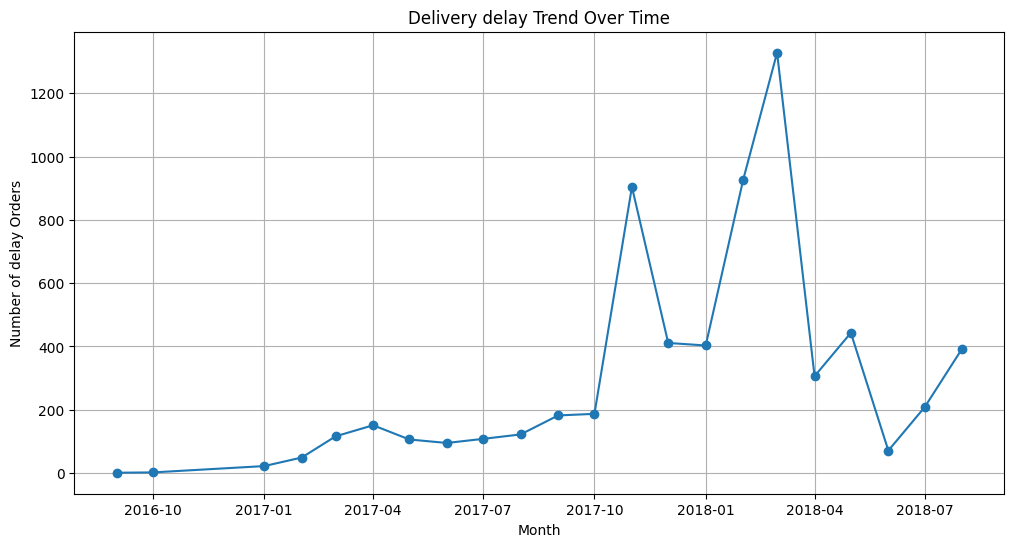

In [250]:
plt.figure(figsize=(12,6))
plt.plot(monthly_delay['order_purchase_timestamp'], monthly_delay['count'], marker='o')
plt.title('Delivery delay Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Number of delay Orders')
plt.grid(True)
plt.show()


In [251]:
delay_trend.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,delivery_status,delay_delivery
52277,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,54.0,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,Late,36.0
61408,b0cfee6ce5503781be6004e0e31e4309,9e18a290b9d17b14fe33b68a0ea2bfeb,delivered,2016-10-04 18:07:24,2016-10-06 15:43:50,2016-11-21 09:33:44,2016-11-29 15:23:44,2016-11-28,55.0,3c752a5f42170574e38358384ece8819,13425,piracicaba,SP,Late,1.0
45671,5cc475c7c03290048eb2e742cd64cb5e,75e8f990b9e289013b1d092614b52487,delivered,2016-10-04 21:54:52,2016-10-05 03:10:31,2016-12-06 17:24:00,2016-12-12 20:31:54,2016-11-24,68.0,2bf93b9956e26356b52f5d426c7801de,3275,sao paulo,SP,Late,18.0


In [252]:
monthly_avg_delay =delay_trend.groupby(delay_trend['order_purchase_timestamp'].dt.to_period('M'))['delay_delivery'].mean().reset_index()

monthly_avg_delay['order_purchase_timestamp'] = monthly_avg_delay['order_purchase_timestamp'].dt.to_timestamp()

monthly_avg_delay['change'] = monthly_avg_delay['delay_delivery'].diff()
monthly_avg_delay


,order_purchase_timestamp,delay_delivery,change
0,2016-09-01,36.000000,NaN
1,2016-10-01,9.500000,-26.500000
2,2017-01-01,20.227273,10.727273
3,2017-02-01,20.795918,0.568646
4,2017-03-01,25.431034,4.635116
5,2017-04-01,12.337748,-13.093286
6,2017-05-01,12.537736,0.199988
7,2017-06-01,14.263158,1.725422
8,2017-07-01,11.685185,-2.577973
9,2017-08-01,8.786885,-2.898300


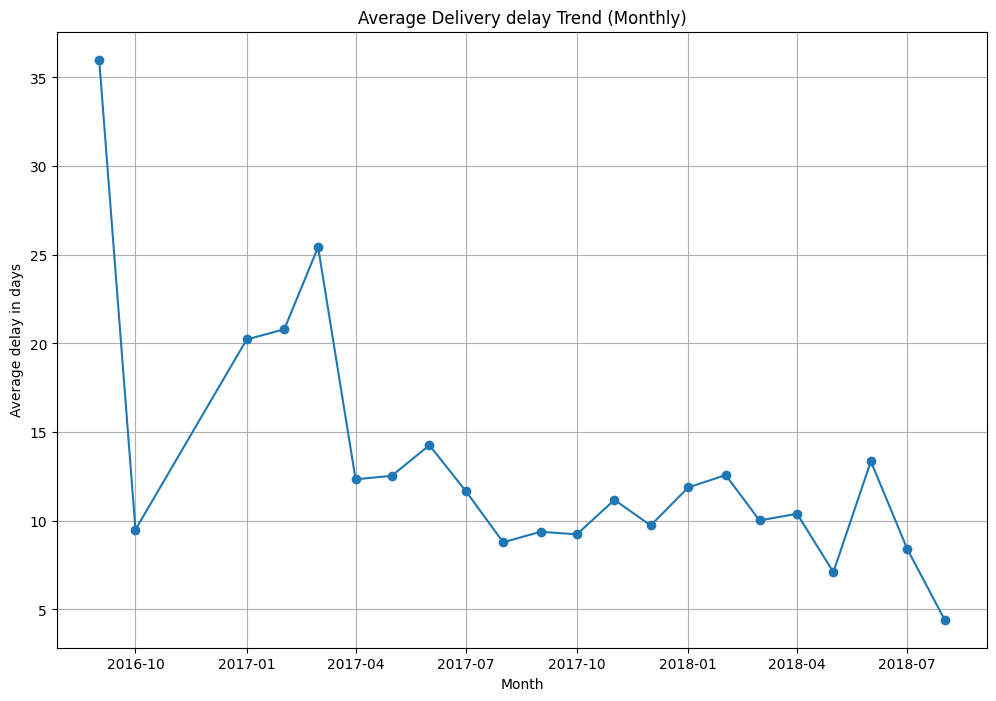

In [253]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.plot(monthly_avg_delay['order_purchase_timestamp'], monthly_avg_delay['delay_delivery'], marker='o')
plt.title('Average Delivery delay Trend (Monthly)')
plt.xlabel('Month')
plt.ylabel('Average delay in days')
plt.grid(True)
plt.show()


**Even though the delay in order deliver show increasing trend with respect to time but the delay time between order delivered time and estimated order delivered time show decreasing trend with respect to time**

# Customer Satisfaction Analysis

In [254]:
delay_trend

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,delivery_status,delay_delivery
52277,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,54.0,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,Late,36.0
61408,b0cfee6ce5503781be6004e0e31e4309,9e18a290b9d17b14fe33b68a0ea2bfeb,delivered,2016-10-04 18:07:24,2016-10-06 15:43:50,2016-11-21 09:33:44,2016-11-29 15:23:44,2016-11-28,55.0,3c752a5f42170574e38358384ece8819,13425,piracicaba,SP,Late,1.0
45671,5cc475c7c03290048eb2e742cd64cb5e,75e8f990b9e289013b1d092614b52487,delivered,2016-10-04 21:54:52,2016-10-05 03:10:31,2016-12-06 17:24:00,2016-12-12 20:31:54,2016-11-24,68.0,2bf93b9956e26356b52f5d426c7801de,3275,sao paulo,SP,Late,18.0
82080,89898719573722b59b173f76fb213501,d2b141e8cefd8acb97baee4b25b01ea5,delivered,2017-01-07 00:34:47,2017-01-07 00:50:15,2017-01-10 14:52:35,2017-03-06 13:15:00,2017-02-15,58.0,b598d6591ec1faa44e378483e526953b,8142,sao paulo,SP,Late,19.0
28916,acc3d4031cbd2f28ac6b5b71427a054c,4a929b369cfa8293f0a22f9a65ad4b1d,delivered,2017-01-09 21:40:42,2017-01-09 21:55:11,2017-01-11 12:23:58,2017-03-02 10:57:46,2017-02-07,51.0,d93129fd763bf7f5541e5e69dcc2830e,24855,itaborai,RJ,Late,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67495,38289de96763d9d81470f67583f4b2f0,ad6891a1937cb8723a2c08ba1ae59873,delivered,2018-08-22 11:49:11,2018-08-23 02:44:21,2018-08-23 12:39:00,2018-08-29 19:48:37,2018-08-27,7.0,9dbb05f5577e862337b93feb8f358839,65058,sao luis,MA,Late,2.0
78370,fe225fc0702b1d46a931e88d60c7be25,c90e1fc62717b61b9e82c4ae6f32bb2d,delivered,2018-08-22 15:45:32,2018-08-23 02:44:25,2018-08-28 20:35:00,2018-08-29 16:32:11,2018-08-27,7.0,c562fe6c90802bff033da0a536e4d972,3066,sao paulo,SP,Late,2.0
82347,133a123493a55f389917093bd41fb184,d35a891df4b2a8cca3a334a3435ecaa5,delivered,2018-08-23 13:23:25,2018-08-23 13:35:20,2018-08-24 12:56:00,2018-08-29 21:33:48,2018-08-28,6.0,23d9d9b79db36044970fbba2b6a6236f,4846,sao paulo,SP,Late,1.0
92145,478116017852df9d1ac392abcf28927f,ecd37231a9052d49db278a6b92d28054,delivered,2018-08-24 13:59:41,2018-08-24 14:24:25,2018-08-30 14:58:00,2018-09-03 17:18:42,2018-08-29,10.0,f0e7fd85ce6faefbbe702610fb48dd2a,3650,sao paulo,SP,Late,5.0


In [255]:
delay_review=delay_trend.merge(df_order_review,on='order_id',how='inner')

In [256]:
delay_review.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,...,customer_city,customer_state,delivery_status,delay_delivery,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,54.0,830d5b7aaa3b6f1e9ad63703bec97d23,...,sao joaquim da barra,SP,Late,36.0,6916ca4502d6d3bfd39818759d55d536,1,NaN,nao recebi o produto e nem resposta da empresa,2016-10-06 00:00:00,2016-10-07 18:32:28
1,b0cfee6ce5503781be6004e0e31e4309,9e18a290b9d17b14fe33b68a0ea2bfeb,delivered,2016-10-04 18:07:24,2016-10-06 15:43:50,2016-11-21 09:33:44,2016-11-29 15:23:44,2016-11-28,55.0,3c752a5f42170574e38358384ece8819,...,piracicaba,SP,Late,1.0,b212b7df25b4bd6fdc43df8e43c6ed3c,4,NaN,Gostei chegou no prazo e o atendimento fui óti...,2016-11-30 00:00:00,2016-11-30 19:39:33
2,5cc475c7c03290048eb2e742cd64cb5e,75e8f990b9e289013b1d092614b52487,delivered,2016-10-04 21:54:52,2016-10-05 03:10:31,2016-12-06 17:24:00,2016-12-12 20:31:54,2016-11-24,68.0,2bf93b9956e26356b52f5d426c7801de,...,sao paulo,SP,Late,18.0,911489d0bc7092faa2e845b5300acde7,1,NaN,"Comprei um toner samsung, paguei em 04/10/2016...",2016-11-27 00:00:00,2016-11-29 21:57:20
3,89898719573722b59b173f76fb213501,d2b141e8cefd8acb97baee4b25b01ea5,delivered,2017-01-07 00:34:47,2017-01-07 00:50:15,2017-01-10 14:52:35,2017-03-06 13:15:00,2017-02-15,58.0,b598d6591ec1faa44e378483e526953b,...,sao paulo,SP,Late,19.0,19232d185d499934b048f16285e6d20e,1,NaN,Não recebi até agora! Não indico,2017-02-17 00:00:00,2017-02-23 02:36:21
4,acc3d4031cbd2f28ac6b5b71427a054c,4a929b369cfa8293f0a22f9a65ad4b1d,delivered,2017-01-09 21:40:42,2017-01-09 21:55:11,2017-01-11 12:23:58,2017-03-02 10:57:46,2017-02-07,51.0,d93129fd763bf7f5541e5e69dcc2830e,...,itaborai,RJ,Late,23.0,c2a956b620f13253d6ca604f81a8160c,5,NaN,NaN,2017-02-09 00:00:00,2017-02-11 16:55:24


In [257]:
delay_delivery=delay_review.groupby('review_score')['review_score'].count().reset_index(name='rating_count')
delay_delivery['rating_%']=delay_delivery['rating_count']*100/delay_delivery['rating_count'].sum()
delay_delivery

,review_score,rating_count,rating_%
0,1,3444,53.728549
1,2,556,8.673947
2,3,698,10.889236
3,4,652,10.171607
4,5,1060,16.536661


In [258]:
timely_deliver=df_orders[df_orders['order_estimated_delivery_date']>=df_orders['order_delivered_customer_date']]

In [259]:
timely_review=timely_deliver.merge(df_order_review,on='order_id',how='inner')

In [260]:
review_rate_count=timely_review.groupby('review_score')['review_score'].count().reset_index(name='rating_count')

In [261]:
review_rate_count['rating_%']=review_rate_count['rating_count']*100/review_rate_count['rating_count'].sum()
review_rate_count

,review_score,rating_count,rating_%
0,1,5855,6.604029
1,2,2335,2.633716
2,3,7086,7.992511
3,4,18033,20.339958
4,5,55349,62.429786


***When order were delivered late 53% customer gave 
1 star review on the other hand when orders deliver timely then 62.42 percent people give 5 star rating .
Conclusion: Delivery time impact customer behavior towards product.***

In [262]:
prd_analysis=df_product_cat.merge(df_products,on='product_category_name',how='outer')
prd_analysis=prd_analysis.merge(df_order_items,on='product_id',how='outer')
prd_analysis=prd_analysis.merge(df_order_review,on='order_id',how='inner')

In [263]:
prd_analysis_mean=prd_analysis.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).reset_index()

In [264]:
print(prd_analysis_mean)

   product_category_name_english  review_score
0              cds_dvds_musicals      4.642857
1      fashion_childrens_clothes      4.500000
2         books_general_interest      4.446266
3        costruction_tools_tools      4.444444
4                        flowers      4.419355
..                           ...           ...
66         fashion_male_clothing      3.641221
67                home_comfort_2      3.629630
68              office_furniture      3.493183
69           diapers_and_hygiene      3.256410
70         security_and_services      2.500000

[71 rows x 2 columns]


**Security and services categories are least rated products with an average rating of 2.2 followed by diapers & hygiene and office furniture.**

In [265]:
prd_analysis.groupby('product_category_name_english')['review_score'].median().sort_values(ascending=False).reset_index()

,product_category_name_english,review_score
0,agro_industry_and_commerce,5.0
1,air_conditioning,5.0
2,art,5.0
3,arts_and_craftmanship,5.0
4,audio,5.0
...,...,...
66,fixed_telephony,4.0
67,office_furniture,4.0
68,home_comfort_2,4.0
69,diapers_and_hygiene,3.0


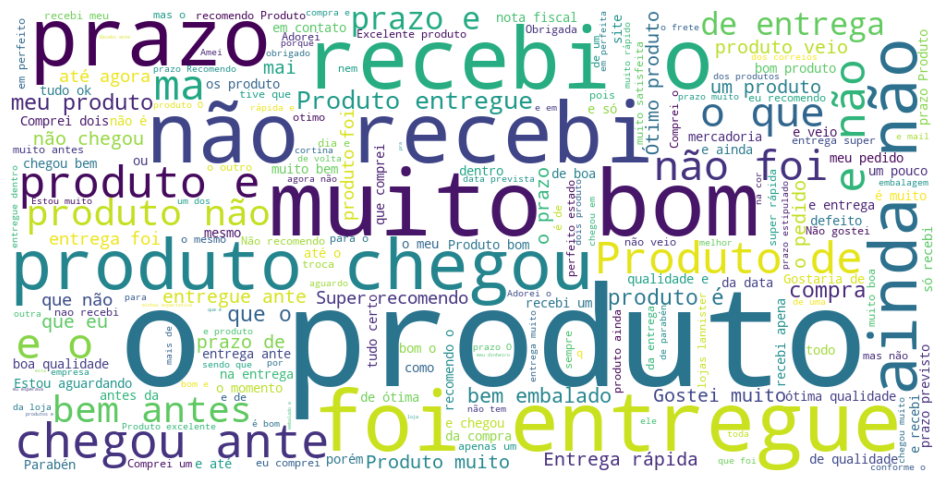

In [266]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
clean=seller_analysis['review_comment_message'].dropna()
# Combine all reviews
text = " ".join(str(review) for review in clean)

# Generate Word Cloud with built-in stopwords
wordcloud = WordCloud(width=1000, height=500,
                      background_color="white",
                      stopwords=STOPWORDS,
                      colormap="viridis",
                      max_font_size=150).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [267]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,delivery_status,delay_delivery
0,5f79b5b0931d63f1a42989eb65b9da6e,00012a2ce6f8dcda20d059ce98491703,delivered,2017-11-14 16:08:26,2017-11-14 16:35:32,2017-11-17 15:32:08,2017-11-28 15:41:30,2017-12-04,13.0,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP,On Time,-6.0
1,a44895d095d7e0702b6a162fa2dbeced,000161a058600d5901f007fab4c27140,delivered,2017-07-16 09:40:32,2017-07-16 09:55:12,2017-07-19 19:09:37,2017-07-25 18:57:33,2017-08-04,9.0,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG,On Time,-10.0
2,316a104623542e4d75189bb372bc5f8d,0001fd6190edaaf884bcaf3d49edf079,delivered,2017-02-28 11:06:43,2017-02-28 11:15:20,2017-03-01 15:24:20,2017-03-06 08:57:49,2017-03-22,5.0,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES,On Time,-16.0
3,5825ce2e88d5346438686b0bba99e5ee,0002414f95344307404f0ace7a26f1d5,delivered,2017-08-16 13:09:20,2017-08-17 03:10:27,2017-08-19 11:34:29,2017-09-13 20:06:02,2017-09-14,28.0,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG,On Time,-1.0
4,0ab7fb08086d4af9141453c91878ed7a,000379cdec625522490c315e70c7a9fb,delivered,2018-04-02 13:42:17,2018-04-04 03:10:19,2018-04-04 18:11:09,2018-04-13 20:21:08,2018-04-18,11.0,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP,On Time,-5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,814d6a3a7c0b32b2ad929ac6328124e9,fffecc9f79fd8c764f843e9951b11341,delivered,2018-03-29 16:59:26,2018-03-29 17:10:27,2018-03-31 14:29:38,2018-04-10 17:20:49,2018-04-27,12.0,e5794df8573fa179a90a7b797fc4b71f,95630,parobe,RS,On Time,-17.0
99437,8c855550908247a7eff50281b92167a8,fffeda5b6d849fbd39689bb92087f431,delivered,2018-05-22 13:36:02,2018-05-22 13:54:37,2018-05-25 13:25:00,2018-06-08 18:03:31,2018-06-29,17.0,afbb5a642107cf6bb1ca68e863175f03,22461,rio de janeiro,RJ,On Time,-21.0
99438,83b5fc912b2862c5046555ded1483ae9,ffff42319e9b2d713724ae527742af25,delivered,2018-06-13 16:57:05,2018-06-13 17:20:23,2018-06-15 18:52:00,2018-06-18 18:33:05,2018-06-25,5.0,680213db6ebd9e4f24d03280cbe10346,6754,taboao da serra,SP,On Time,-7.0
99439,d0e7be325a1c986babc4e1cdb91edc03,ffffa3172527f765de70084a7e53aae8,delivered,2017-09-02 11:53:32,2017-09-02 12:05:40,2017-09-08 20:04:11,2017-09-14 19:47:40,2017-09-26,12.0,48fd7dec70f2b104a1d5e8c5c639102b,37130,alfenas,MG,On Time,-12.0


In [268]:
customer_analysis=df_orders[(df_orders['order_status'] != 'canceled') & (df_orders['order_status'] != 'unavailable')]

In [269]:
customer_analysis.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_time', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'delivery_status', 'delay_delivery'],
      dtype='object')

In [270]:
customer_analysis=df_customer_info.merge(customer_analysis,on='customer_id',how='inner')
customer_analysis

,customer_id,customer_unique_id_x,customer_zip_code_prefix_x,customer_city_x,customer_state_x,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id_y,customer_zip_code_prefix_y,customer_city_y,customer_state_y,delivery_status,delay_delivery
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,8.0,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,On Time,-11.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,16.0,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,On Time,-8.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,26.0,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,Late,1.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,14.0,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,On Time,-13.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,11.0,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,On Time,-6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98202,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,6.0,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,On Time,-12.0
98203,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,7.0,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,On Time,-9.0
98204,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,30.0,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,Late,7.0
98205,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,12.0,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,On Time,-19.0


In [271]:
for column in customer_analysis.columns:
    if '_y' in column:
        customer_analysis.drop(columns=column,inplace=True)
customer_analysis

,customer_id,customer_unique_id_x,customer_zip_code_prefix_x,customer_city_x,customer_state_x,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delivery_status,delay_delivery
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,8.0,On Time,-11.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,16.0,On Time,-8.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,26.0,Late,1.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,14.0,On Time,-13.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,11.0,On Time,-6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98202,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,6.0,On Time,-12.0
98203,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,7.0,On Time,-9.0
98204,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,30.0,Late,7.0
98205,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,12.0,On Time,-19.0


In [272]:
customer_analysis.rename(columns={'customer_unique_id_x':'customer_unique_id'},inplace=True)

In [273]:
# Sort by customer and date
customer_analysis = customer_analysis.sort_values(['customer_unique_id','order_purchase_timestamp'])

# Calculate next order date per customer
customer_analysis['next_order_date'] = customer_analysis.groupby('customer_unique_id')['order_purchase_timestamp'].shift(-1)

# Calculate days until repeat order
customer_analysis['days_until_repeat'] = (customer_analysis['next_order_date'] - customer_analysis['order_purchase_timestamp']).dt.days

In [274]:
customer_analysis.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix_x,customer_city_x,customer_state_x,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delivery_status,delay_delivery,next_order_date,days_until_repeat
63221,fadbb3709178fc513abc1b2670aa1ad2,0000366f3b9a7992bf8c76cfdf3221e2,7787,cajamar,SP,e22acc9c116caa3f2b7121bbb380d08e,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,6.0,On Time,-5.0,NaT,NaN
24302,4cb282e167ae9234755102258dd52ee8,0000b849f77a49e4a4ce2b2a4ca5be3f,6053,osasco,SP,3594e05a005ac4d06a72673270ef9ec9,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,3.0,On Time,-5.0,NaT,NaN
40360,9b3932a6253894a02c1df9d19004239f,0000f46a3911fa3c0805444483337064,88115,sao jose,SC,b33ec3b699337181488304f362a6b734,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07,25.0,On Time,-2.0,NaT,NaN


In [275]:
customer_retention=customer_analysis[customer_analysis['days_until_repeat'].notna()]

In [276]:
customer_retention[customer_retention['days_until_repeat']==0].count()

customer_id                      965
customer_unique_id               965
customer_zip_code_prefix_x       965
customer_city_x                  965
customer_state_x                 965
order_id                         965
order_status                     965
order_purchase_timestamp         965
order_approved_at                965
order_delivered_carrier_date     957
order_delivered_customer_date    942
order_estimated_delivery_date    965
delivery_time                    942
delivery_status                  942
delay_delivery                   942
next_order_date                  965
days_until_repeat                965
dtype: int64

In [277]:
df_orders['customer_id'].count()-df_orders['customer_unique_id'].nunique()

np.int64(3345)

# STATISTICAL HYPOTHESIS


Late delivery impact the overall customer review.
Customer live in cities that has most orders also purchase most of expensive products.  

In [278]:
delay_trend.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,delivery_status,delay_delivery
52277,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,54.0,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,Late,36.0
61408,b0cfee6ce5503781be6004e0e31e4309,9e18a290b9d17b14fe33b68a0ea2bfeb,delivered,2016-10-04 18:07:24,2016-10-06 15:43:50,2016-11-21 09:33:44,2016-11-29 15:23:44,2016-11-28,55.0,3c752a5f42170574e38358384ece8819,13425,piracicaba,SP,Late,1.0
45671,5cc475c7c03290048eb2e742cd64cb5e,75e8f990b9e289013b1d092614b52487,delivered,2016-10-04 21:54:52,2016-10-05 03:10:31,2016-12-06 17:24:00,2016-12-12 20:31:54,2016-11-24,68.0,2bf93b9956e26356b52f5d426c7801de,3275,sao paulo,SP,Late,18.0
82080,89898719573722b59b173f76fb213501,d2b141e8cefd8acb97baee4b25b01ea5,delivered,2017-01-07 00:34:47,2017-01-07 00:50:15,2017-01-10 14:52:35,2017-03-06 13:15:00,2017-02-15,58.0,b598d6591ec1faa44e378483e526953b,8142,sao paulo,SP,Late,19.0
28916,acc3d4031cbd2f28ac6b5b71427a054c,4a929b369cfa8293f0a22f9a65ad4b1d,delivered,2017-01-09 21:40:42,2017-01-09 21:55:11,2017-01-11 12:23:58,2017-03-02 10:57:46,2017-02-07,51.0,d93129fd763bf7f5541e5e69dcc2830e,24855,itaborai,RJ,Late,23.0


In [279]:
delay_trend=delay_trend.merge(df_order_review,on='order_id',how='inner')

In [280]:
delay=delay_trend[delay_trend['delivery_status']=='Late']

In [281]:
delay=delay[['delivery_status','review_score']]

In [282]:
delay

,delivery_status,review_score
0,Late,1
1,Late,4
2,Late,1
3,Late,1
4,Late,5
...,...,...
6405,Late,5
6406,Late,4
6407,Late,5
6408,Late,1


In [283]:
df_orders['is_late']=df_orders['delivery_status'].map({'On Time':0,'Late':1})

In [284]:
delay=df_orders[df_orders['order_status']=='delivered'].dropna()

In [285]:
delay['is_late']=delay['is_late'].astype(int)

In [286]:
delay=delay.merge(df_order_review,on='order_id',how='inner')

In [287]:
delay=delay[['is_late','review_score']].dropna()

In [288]:
delay['is_late'].unique()

array([0, 1])

#  HYPOTHESIS TESTING

H₀ (Null)

Late deliveries do not affect review scores.

H₁ (Alternative)

Late deliveries reduce review scores.

In [289]:
from scipy.stats import ttest_ind

# Create groups
late = delay.loc[delay['is_late'] == 1, 'review_score'].dropna()
ontime = delay.loc[delay['is_late'] == 0, 'review_score'].dropna()

# Summary Statistics
print("="*50)
print("SUMMARY STATISTICS")
print("="*50)

summary = delay.groupby('is_late')['review_score'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
)

print(summary)

# Hypothesis Test
# H0: Late deliveries do not affect review scores
# H1: Late deliveries affect review scores

t_stat, p_value = ttest_ind(
    late,
    ontime,
    equal_var=False
)

print("\n" + "="*50)
print("WELCH T-TEST RESULTS")
print("="*50)

print(f"T Statistic : {t_stat:.4f}")
print(f"P Value     : {p_value:.10f}")

# Decision
alpha = 0.05

print("\n" + "="*50)
print("HYPOTHESIS DECISION")
print("="*50)

if p_value < alpha:
    print("Reject the Null Hypothesis (H0)")
    print("Late delivery has a statistically significant impact on review scores.")
else:
    print("Fail to Reject the Null Hypothesis (H0)")
    print("No statistically significant difference found.")

# Business Interpretation
print("\n" + "="*50)
print("BUSINESS INTERPRETATION")
print("="*50)

late_mean = late.mean()
ontime_mean = ontime.mean()

print(f"Average Review Score (Late Orders)    : {late_mean:.2f}")
print(f"Average Review Score (On-Time Orders) : {ontime_mean:.2f}")

if late_mean < ontime_mean:
    print(
        f"\nCustomers receiving late deliveries gave "
        f"{ontime_mean - late_mean:.2f} fewer review points on average."
    )
else:
    print(
        f"\nCustomers receiving late deliveries gave "
        f"{late_mean - ontime_mean:.2f} more review points on average."
    )

SUMMARY STATISTICS
         count      mean  median       std  min  max
is_late                                             
0        89930  4.289970     5.0  1.149741    1    5
1         6408  2.270599     1.0  1.570903    1    5

WELCH T-TEST RESULTS
T Statistic : -100.9936
P Value     : 0.0000000000

HYPOTHESIS DECISION
Reject the Null Hypothesis (H0)
Late delivery has a statistically significant impact on review scores.

BUSINESS INTERPRETATION
Average Review Score (Late Orders)    : 2.27
Average Review Score (On-Time Orders) : 4.29

Customers receiving late deliveries gave 2.02 fewer review points on average.


In [290]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Late delivery significantly affects review score.")
else:
    print("Fail to Reject H0")

Reject H0
Late delivery significantly affects review score.


Hypothesis 2

H₀

Cities with higher order volume do not have higher repeat-customer rates.

H₁

Cities with higher order volume have higher repeat-customer rates.

In [291]:
order_volume=df_orders.merge(df_order_payment,on='order_id',how='inner')

In [292]:
citywise_order_payment=order_volume.groupby("customer_city").agg(order_count=("order_id","count"),payment_sum=('payment_value','sum')).reset_index()

In [293]:
import numpy as np
from scipy import stats

# Split cities into high vs low order groups
group_split = 3000

high_order_sales = citywise_order_payment[citywise_order_payment['order_count'] > group_split]['payment_sum']
low_order_sales = citywise_order_payment[citywise_order_payment['order_count'] <= group_split]['payment_sum']

# Calculate means and standard deviations
mean_high = np.mean(high_order_sales)
mean_low = np.mean(low_order_sales)
std_high = np.std(high_order_sales, ddof=1)
std_low = np.std(low_order_sales, ddof=1)

n_high = len(high_order_sales)
n_low = len(low_order_sales)

# Z-test formula
z_stat = (mean_high - mean_low) / np.sqrt((std_high**2 / n_high) + (std_low**2 / n_low))

# Two-tailed p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("Z-statistic:", z_stat)
print("P-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("✅ Reject H0: Cities with higher orders have significantly higher sales.")
else:
    print("❌ Fail to reject H0: No significant difference in sales between high and low order cities.")


Z-statistic: 3.2254758151000287
P-value: 0.0012576346090353852
✅ Reject H0: Cities with higher orders have significantly higher sales.


In [294]:
citywise_order_payment.corr(numeric_only=True)

,order_count,payment_sum
order_count,1.000000,0.996862
payment_sum,0.996862,1.000000


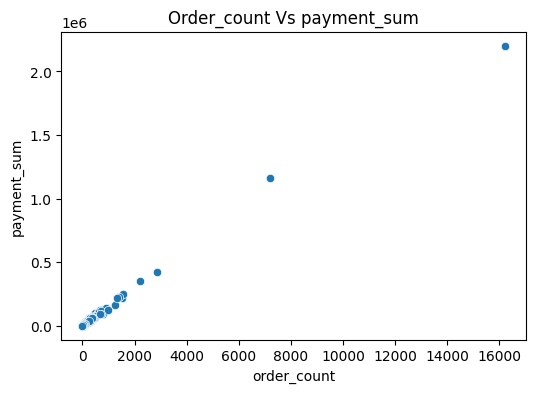

In [295]:
plt.figure(figsize=(6,4))
ax=sns.scatterplot(data=citywise_order_payment,x='order_count',y='payment_sum')
plt.title("Order_count Vs payment_sum")
plt.show()

In [296]:
# df_orders.merge(df_customer_info,on=''

# Cities with most customers also has most repeated orders

In [297]:
city_order=df_customer_info.merge(df_orders,on='customer_id',how='inner')

In [298]:
city_order.columns

Index(['customer_id', 'customer_unique_id_x', 'customer_zip_code_prefix_x',
       'customer_city_x', 'customer_state_x', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'delivery_time',
       'customer_unique_id_y', 'customer_zip_code_prefix_y', 'customer_city_y',
       'customer_state_y', 'delivery_status', 'delay_delivery', 'is_late'],
      dtype='object')

In [299]:
city_cust_order=city_order.groupby(['customer_city_y','customer_unique_id_x']).agg(order_count=('order_id','count')).reset_index()

In [300]:
city_cust_order

,customer_city_y,customer_unique_id_x,order_count
0,abadia dos dourados,64ee476500a01beb94df40f97a108c50,1
1,abadia dos dourados,afddf43a03a9941624ed42c0b2c17280,1
2,abadia dos dourados,e1feae9083c4c2895ddf6dc80526a85d,1
3,abadiania,8d76b559181609308fcae630ea64cd61,1
4,abaete,1605eaf5744972f09529a6ce287e9e47,1
...,...,...,...
96214,ze doca,a897335a844c6cb0c0f25a75f43092b4,1
96215,ze doca,c933181d09535cb6bdfb1c0160323bd9,1
96216,ze doca,d4798889fe74026a739ca0be9d2dccb8,1
96217,zortea,09a3f87b74828b274d73ee9dfef43b68,1


In [301]:
city_repeat_cust=city_cust_order[city_cust_order['order_count']>1]

In [302]:
city_repeat_cust

,customer_city_y,customer_unique_id_x,order_count
54,abreu e lima,8fe4f9a0d6a47babbd498127a9109bd1,2
57,abreu e lima,a0e0770d529c5da6dd71d5be8620aa3b,2
75,acarau,c7c19110042036e6266adc998cbf1289,3
119,adamantina,bfe1ecef0f01ad67e5e0cf1860e94e60,2
176,agua boa,bd0512ab6c631a62fdc974a682600f56,2
...,...,...,...
96118,votuporanga,c1977e8e3ea0900e70cd1dd70123d382,2
96148,xambre,27eecff5a6338f7c36c78ad05eacc575,2
96154,xangri-la,e38a9d13896946501404c6d82790728c,2
96168,xanxere,967eb85deeab5124df2165cdada917f3,2


In [303]:
city_repeat_order=city_repeat_cust.groupby("customer_city_y")['order_count'].count().sort_values(ascending=False).reset_index(name='repeated_cust')

In [304]:
city_repeat_order.head(3)

,customer_city_y,repeated_cust
0,sao paulo,502
1,rio de janeiro,236
2,belo horizonte,92


In [305]:
cust_order=df_orders.groupby("customer_city")["order_id"].count().reset_index(name="order_count")

In [306]:
cust_order.head(3)

,customer_city,order_count
0,abadia dos dourados,3
1,abadiania,1
2,abaete,12


In [307]:
city_repeat_oc=city_repeat_order.merge(cust_order,left_on="customer_city_y",right_on="customer_city",how="inner")

In [308]:
city_repeat_oc=city_repeat_oc[["customer_city","repeated_cust","order_count"]]

In [309]:
city_repeat_oc

,customer_city,repeated_cust,order_count
0,sao paulo,502,15540
1,rio de janeiro,236,6882
2,belo horizonte,92,2773
3,brasilia,60,2131
4,curitiba,44,1521
...,...,...,...
775,alpinopolis,1,7
776,almirante tamandare,1,35
777,alfredo chaves,1,7
778,alfenas,1,43


In [310]:
city_repeat_oc.corr(numeric_only=True)

,repeated_cust,order_count
repeated_cust,1.00000,0.99698
order_count,0.99698,1.00000
